# **Evaluación 2**

Programación cientifica, 2026-1

Alexa Marly Osorio Cano

Universidad Nacional - facultad de ciencias

##**1.** cargar los datos

In [1]:
import numpy as np

In [2]:
import os
from google.colab import drive

# Si estamos en Colab, montamos Drive solo para clonar/acceder al repo
# Pero si el archivo está en la misma carpeta que el notebook, esto basta:
if os.path.exists('datos_2773.npz'):
    # archivo en la misma carpeta que el notebook (caso GitHub/local)
    ruta = 'datos_2773.npz'
else:
    # fallback: montar Drive (caso tu sesión personal)
    drive.mount('/content/drive')
    ruta = '/content/drive/MyDrive/programación científica /datos_2773.npz'

data = np.load(ruta, allow_pickle=True)
print(f"Datos cargados desde: {ruta}")

Mounted at /content/drive
Datos cargados desde: /content/drive/MyDrive/programación científica /datos_2773.npz


In [3]:
X = data['X']   # señales: (45, 256)
y = data['y']   # etiquetas de régimen: (45,)
t = data['t']   # vector de tiempo: (256,)

print("Claves del archivo:", list(data.keys()))
print(f"X shape: {X.shape}   → {X.shape[0]} señales de longitud {X.shape[1]}")
print(f"y shape: {y.shape}   → etiquetas de régimen")
print(f"t shape: {t.shape}   → vector de tiempo")
print(f"\nRégimen 0 (sin dispersión): {(y==0).sum()} señales")
print(f"Régimen 1 (intermedio):      {(y==1).sum()} señales")
print(f"Régimen 2 (fuerte):          {(y==2).sum()} señales")
print(f"\nt[0]={t[0]:.4f}  t[-1]={t[-1]:.4f}  Δt={t[1]-t[0]:.6f}")

Claves del archivo: ['X', 'y', 't', 'meta']
X shape: (45, 256)   → 45 señales de longitud 256
y shape: (45,)   → etiquetas de régimen
t shape: (256,)   → vector de tiempo

Régimen 0 (sin dispersión): 15 señales
Régimen 1 (intermedio):      15 señales
Régimen 2 (fuerte):          15 señales

t[0]=0.0000  t[-1]=0.9961  Δt=0.003906


##**2.** inspeccionar valores de X y Y

In [4]:
print("═══ X (señales) ═══")
print(f"Mínimo:          {X.min():.4f}")
print(f"Máximo:          {X.max():.4f}")
print(f"Media:           {X.mean():.4f}")
print(f"Desv. estándar:  {X.std():.4f}")

print("\n═══ y (etiquetas) ═══")
print(f"Valores únicos: {np.unique(y)}")

print("\n═══ t (tiempo) ═══")
print(f"Primer valor:  {t[0]:.4f}")
print(f"Último valor:  {t[-1]:.4f}")
print(f"Número de puntos: {len(t)}")

═══ X (señales) ═══
Mínimo:          -2.3851
Máximo:          2.3325
Media:           -0.0002
Desv. estándar:  0.7866

═══ y (etiquetas) ═══
Valores únicos: [0 1 2]

═══ t (tiempo) ═══
Primer valor:  0.0000
Último valor:  0.9961
Número de puntos: 256


X — las señales

* Hay 15 señales por cada regimen (y) 45 señales en total
* Mínimo -2.38 y Máximo 2.33 — las señales oscilan entre esos valores. porque cada señal es una suma de cosenos f(t)=∑j ajcos⁡(ωjt+φj)f(t) — las amplitudes aj pueden sumarse o cancelarse, dando valores entre -2 y 2 aproximadamente.
* Media ≈ 0 —  Los cosenos oscilan simétricamente alrededor de cero, así que promediando muchos valores y muchas señales el resultado es prácticamente cero.
* Desv. estándar 0.79 — mide cuánto se alejan típicamente los valores de la media. Como la media es 0, esto nos dice que los valores "típicos" de las señales están a ±0.79 de cero



y — las etiquetas
* Solo tiene tres valores posibles: 0, 1, 2 — que corresponden a los tres regímenes físicos del enunciado: sin dispersión, intermedio y fuerte. Es simplemente una etiqueta que nos dice de qué tipo es cada señal. La red no usa y para entrenarse — nosotros la usamos para separar las señales por régimen al analizar resultados.



t — el vector de tiempo
* Va de 0 a 0.9961 en 256 puntos.
* Este vector es el mismo para todas las señales — todas están muestreadas en los mismos 256 instantes de tiempo. Por eso X tiene shape (45, 256): 45 señales evaluadas en los mismos 256 puntos de t

##**3.** visualizar señales, una por regimen

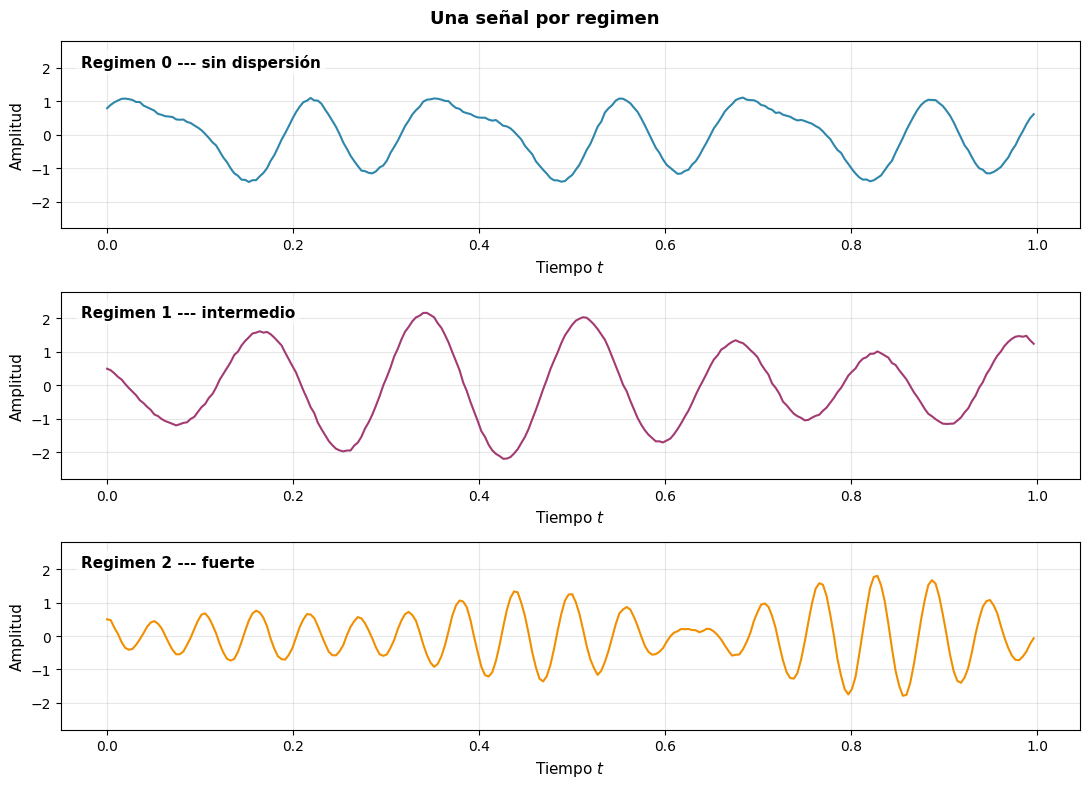

In [5]:
import matplotlib.pyplot as plt

nombres = {
    0: r'Regimen 0 --- sin dispersión',
    1: r'Regimen 1 --- intermedio',
    2: r'Regimen 2 --- fuerte'
}
colores = {0: '#2E86AB', 1: '#A23B72', 2: '#F18F01'}

fig, axes = plt.subplots(3, 1, figsize=(11, 8))

for ax, reg in zip(axes, [0, 1, 2]):
    x_sig = X[y == reg][0]
    ax.plot(t, x_sig, color=colores[reg], lw=1.5)

    # título dentro de la gráfica como texto
    ax.text(0.02, 0.93, nombres[reg],
            transform=ax.transAxes,
            fontsize=11, fontweight='bold',
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white', alpha=0.7, edgecolor='none'))

    ax.set_ylabel('Amplitud', fontsize=11)
    ax.set_xlabel('Tiempo $t$', fontsize=11)
    ax.set_ylim(-2.8, 2.8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Una señal por regimen', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##**4.** calcular la energia media del dataset

In [6]:
energia_media = (X**2).mean()
print(f"Energía media del dataset: {energia_media:.3f}")

Energía media del dataset: 0.619


¿Qué significa esto matemáticamente?

La energía de una señal discreta x de longitud N se define como:

E = $\frac{1}{N} \sum_{n=0}^{N-1}x[n]^2$

Y (X**2).mean() hace exactamente eso pero promediando sobre todas las señales y todos los puntos a la vez — es decir:

Energia media = $\frac{1}{45*256} \sum_{i=0}^{44}\sum_{n=0}^{255}x_i​[n]^2$

Es una medida de qué tan "grandes" son las señales en promedio.




##**5.** Construir la capa de Fourier

In [7]:
K = 15   # número de frecuencias

def fourier_W1(K, t):
    """
    Construye W1 de tamaño (2K, N) donde:
      - fila 2k-2 : cos(2π k t),  k = 1..K
      - fila 2k-1 : sin(2π k t),  k = 1..K
    W1 @ x reproduce los coeficientes de Fourier de x.
    """
    rows = []
    for k in range(1, K + 1):
        rows.append(np.cos(2 * np.pi * k * t))   # fila par   → coseno
        rows.append(np.sin(2 * np.pi * k * t))   # fila impar → seno
    return np.stack(rows, axis=0)                 # (2K, N)

W1_fourier = fourier_W1(K, t)
print(f"Shape de W1_fourier: {W1_fourier.shape}")

Shape de W1_fourier: (30, 256)


¿Qué hace cada parte?

range(1, K+1) — iteramos k=1,2,…,15. Empezamos en 1 porque k=0k=0
k=0 sería cos⁡(0)=1 — una fila constante que no aporta información de frecuencia.

np.cos(2 * np.pi * k * t) — evalúa el coseno en los 256 puntos de t. El resultado es un vector de 256 valores.

rows.append(...) — vamos acumulando las filas de la matriz. El orden es cos, sin, cos, sin... para cada frecuencia.

La matriz completa se ve así:

$$ W_1 = \begin{pmatrix}
\cos(2\pi \cdot 1 \cdot t) \\
\sin(2\pi \cdot 1 \cdot t) \\
\cos(2\pi \cdot 2 \cdot t) \\
\sin(2\pi \cdot 2 \cdot t) \\
\vdots \\
\cos(2\pi \cdot 15 \cdot t) \\
\sin(2\pi \cdot 15 \cdot t)
\end{pmatrix} \in \mathbb{R}^{30 \times 256} $$

Cuando multiplicamos $W_1​\cdot x$, cada fila hace un producto punto con la señal — que es exactamente la definición de los coeficientes de Fourier



##**6.** comparar con np.fft

In [8]:
# Tomamos una señal de prueba (la primera del régimen 0)
x0 = X[y == 0][0]   # (256,)

# Proyección de W1 sobre la señal (producto matricial)
coefs_capa = W1_fourier @ x0   # (30,) — coeficientes de nuestra capa

# FFT de referencia con numpy
fft_x0 = np.fft.fft(x0)   # (256,) — transformada completa

# Extraemos los coeficientes para k=1..K en el mismo orden que nuestra capa
# Re(FFT[k]) = suma cos → coeficiente de coseno
# -Im(FFT[k]) = suma sin → coeficiente de seno
coefs_fft = np.empty(2 * K)
coefs_fft[0::2] =  fft_x0.real[1:K+1]   # cosenos: posiciones pares
coefs_fft[1::2] = -fft_x0.imag[1:K+1]   # senos:   posiciones impares

# Error máximo entre ambos
err_max = np.abs(coefs_capa - coefs_fft).max()
print(f"Error máximo absoluto (capa Fourier vs np.fft): {err_max:.2e}")



Error máximo absoluto (capa Fourier vs np.fft): 7.90e-14


Podemos evidenciar que la capa reproduce la transformada de Fourier de la señal, pues el error maximo adsoluto es practicamente cero (7.90e-14).

Ósea que Que nuestra matriz $W_1$ hace exactamente el mismo cálculo que np.fft — descompone la señal en sus frecuencias.

##**7.** construir la red en Jax

In [9]:
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap

# Dimensiones fijas de la arquitectura
N = 256   # longitud de cada señal (número de puntos en el tiempo)
K = 15    # número de frecuencias de la capa Fourier → la red tendrá 2K = 30 neuronas ocultas

# ── Inicialización Fourier ───────────────────────────────────────────────
def init_fourier(K, t, key):
    # JAX no tiene aleatoriedad global — hay que partir una key en subkeys
    # independientes, una por cada operación aleatoria
    k2, = jax.random.split(key, 1)
    return {
        # W1 se fija como la matriz Fourier construida antes:
        # sus filas son cos(2πkt) y sin(2πkt) para k=1..K
        # esto hace que W1 @ x calcule los coeficientes de Fourier de x
        'W1': jnp.array(W1_fourier),                    # (2K, N) = (30, 256)

        # los sesgos de la capa oculta se inicializan en cero
        # (no queremos desplazamiento inicial en las activaciones)
        'b1': jnp.zeros(2 * K),                         # (2K,) = (30,)

        # W2 se inicializa aleatoria y pequeña (* 0.1) para que
        # la red parta cerca de cero y el gradiente descendente sea estable
        'W2': jax.random.normal(k2, (N, 2*K)) * 0.1,   # (N, 2K) = (256, 30)

        # sesgo de la capa de salida también en cero
        'b2': jnp.zeros(N),                             # (N,) = (256,)
    }

# ── Inicialización aleatoria ─────────────────────────────────────────────
def init_random(K, N, key):
    # necesitamos dos subkeys independientes: una para W1 y otra para W2
    k1, k2 = jax.random.split(key, 2)
    return {
        # W1 también aleatoria pequeña — aquí no hay estructura Fourier,
        # la red aprende sus propias bases desde cero
        'W1': jax.random.normal(k1, (2*K, N)) * 0.1,   # (2K, N) = (30, 256)
        'b1': jnp.zeros(2 * K),                         # (2K,) = (30,)
        'W2': jax.random.normal(k2, (N, 2*K)) * 0.1,   # (N, 2K) = (256, 30)
        'b2': jnp.zeros(N),                             # (N,) = (256,)
    }

# ── Forward pass ─────────────────────────────────────────────────────────
def forward(params, x):
    # implementa x̂ = W2 tanh(W1 x + b1) + b2
    # capa oculta: proyecta x a espacio de 2K coeficientes y aplica tanh
    h = jnp.tanh(params['W1'] @ x + params['b1'])   # (2K,) = (30,)
    # capa de salida: recombina linealmente los 2K valores para reconstruir
    # la señal original de N puntos (sin activación — combinación lineal pura)
    return params['W2'] @ h + params['b2']           # (N,) = (256,)

# ── Función de pérdida ───────────────────────────────────────────────────
def loss_fn(params, X_batch):
    # vmap vectoriza forward sobre todo el batch sin escribir un loop explícito:
    # aplica forward a cada señal x de X_batch de forma eficiente
    preds = vmap(lambda x: forward(params, x))(X_batch)
    # error cuadrático medio (MSE) entre reconstrucciones y señales originales
    # L = (1/N) ||x̂ - x||² promediado sobre todas las señales del batch
    return jnp.mean((preds - X_batch) ** 2)

# ── Gradiente compilado ──────────────────────────────────────────────────
# grad(loss_fn): construye automáticamente la función que calcula
# ∇_θ L respecto al primer argumento (params) — esto es backpropagation
# jit(...): compila esa función la primera vez que se llama para que
# las iteraciones siguientes corran mucho más rápido
grad_loss = jit(grad(loss_fn))

# ── Verificación ─────────────────────────────────────────────────────────
# semilla raíz del generador aleatorio de JAX — fija para reproducibilidad
key = jax.random.PRNGKey(42)

# inicializamos una red de prueba con la capa Fourier
params_prueba = init_fourier(K, t, key)

# verificamos que cada parámetro tiene la forma correcta
for nombre, shape in params_prueba.items():
    print(f"{nombre}: {shape.shape}")

# verificamos que el forward pass produce una salida del tamaño correcto
x_prueba = jnp.array(X[0])           # primera señal del dataset como array JAX
salida   = forward(params_prueba, x_prueba)
print(f"\nEntrada shape:  {x_prueba.shape}")   # esperado: (256,)
print(f"Salida shape:   {salida.shape}")       # esperado: (256,)
print(f"Loss inicial:   {loss_fn(params_prueba, jnp.array(X)):.4f}")  # pérdida antes de entrenar

W1: (30, 256)
b1: (30,)
W2: (256, 30)
b2: (256,)

Entrada shape:  (256,)
Salida shape:   (256,)
Loss inicial:   0.8137


En este paso construimos la arquitectura de la red neuronal (pero aún no la entrenamos), usando las siguientes 4 funciones:

* init_fourier — inicializa los parámetros con $W_1$​ = matriz Fourier que ya construimos. $W_2$ se inicializa aleatoria.

* init_random — inicializa tanto $W_1$ como $W_2$ de forma aleatoria. Es el punto de comparación.

(tanto init_fourier como init_random devuelven un diccionario con los 4 parámetros de la red: $W_1, b_1, W_2, b_2$. La diferencia es solo el punto de partida de $W_1$. Los sesgos siempre empiezan en cero.)

* forward — el pase hacia adelante: dada una señal $x$, calcula $\hat{x}$

* loss_fn — la función de pérdida MSE:        $L = \frac{1}{N}\|\hat{x} - x\|^2$


finalmente jit(grad(loss_fn)) hace dos cosas en una línea: grad construye la función que calcula $\nabla_\theta \mathcal{L}$, y jit la compila para que corra rápido.

##**8.** entrenar con inicializacion Fourier

In [10]:
eta    = 0.05    # tasa de aprendizaje η — controla el tamaño de cada paso del gradiente
n_iter = 3000    # número de iteraciones de gradiente descendente

# diccionario donde guardamos los resultados de cada régimen
resultados_fourier = {}

for reg in [0, 1, 2]:
    # seleccionar las 15 señales del régimen actual y convertirlas a JAX float32
    X_reg = jnp.array(X[y == reg], dtype=jnp.float32)   # (15, 256)

    # inicializar los parámetros con la capa Fourier —
    # W1 parte siendo la matriz de senos y cosenos, W2 aleatoria pequeña
    params = init_fourier(K, t, key)

    hist_loss    = []   # historial de pérdida MSE en cada iteración
    hist_err_rel = []   # historial de error relativo ||x̂-x||/||x|| en cada iteración

    for i in range(n_iter):
        # ── paso del gradiente descendente ──────────────────────────────
        # calcular ∇_θ L: gradiente de la pérdida respecto a todos los parámetros
        g = grad_loss(params, X_reg)

        # actualizar θ ← θ - η·∇L para W1, b1, W2, b2 simultáneamente
        # tree_map recorre el diccionario params y g en paralelo y aplica
        # la operación lambda a cada par de hojas (parámetro, gradiente)
        params = jax.tree_util.tree_map(lambda p, g: p - eta * g, params, g)

        # ── guardar métricas ─────────────────────────────────────────────
        # pérdida MSE actual — float() convierte el array JAX a número Python
        l = float(loss_fn(params, X_reg))

        # reconstrucciones de todas las señales del régimen con los parámetros actuales
        preds = vmap(lambda x: forward(params, x))(X_reg)   # (15, 256)

        # error relativo por señal: ||x̂_i - x_i|| / ||x_i||
        # axis=1 calcula la norma sobre los 256 puntos de cada señal
        # .mean() promedia los 15 errores relativos en un solo número
        err = float((jnp.linalg.norm(preds - X_reg, axis=1) /
                     jnp.linalg.norm(X_reg, axis=1)).mean())

        hist_loss.append(l)
        hist_err_rel.append(err)

    # guardar parámetros finales e historiales para usar en pasos siguientes
    resultados_fourier[reg] = {
        'params'  : params,      # pesos entrenados — se usan para reconstruir señales
        'loss'    : hist_loss,   # curva de convergencia de la pérdida
        'err_rel' : hist_err_rel # curva de convergencia del error relativo
    }

    print(f"Régimen {reg} ✓  |  loss final = {hist_loss[-1]:.4e}  |  err_rel final = {hist_err_rel[-1]:.4f}")

Régimen 0 ✓  |  loss final = 4.7549e-02  |  err_rel final = 0.3257
Régimen 1 ✓  |  loss final = 6.6244e-02  |  err_rel final = 0.2919
Régimen 2 ✓  |  loss final = 6.0858e-02  |  err_rel final = 0.3451




El error relativo,

$err\_rel = \frac{1}{15} \sum_{i=1}^{15} \frac{\| \hat{x}_i - x_i \|}{\| x_i \|}$

nos dice que tanto nos equivocamos al reconstruir las señales, que como podemos observar en lo que imprime el codigo error relativo para los regimenes 0, 1 y 2 fueron 0.3257, 0.2919, 0.3451 respectivamente
















##**9.** entrenar con inicializacion aleatoria

In [11]:
# diccionario donde guardamos los resultados del entrenamiento con inicialización aleatoria
resultados_aleatorio = {}

for reg in [0, 1, 2]:
    # seleccionar las 15 señales del régimen actual y convertirlas a JAX float32
    X_reg = jnp.array(X[y == reg], dtype=jnp.float32)   # (15, 256)

    # ── único cambio respecto al entrenamiento Fourier ───────────────────
    # W1 y W2 se inicializan con valores aleatorios pequeños (* 0.1)
    # la red no tiene ninguna estructura inicial — aprende sus bases desde cero
    params = init_random(K, N, key)

    hist_loss    = []   # historial de pérdida MSE
    hist_err_rel = []   # historial de error relativo ||x̂-x||/||x||

    for i in range(n_iter):
        # calcular ∇_θ L respecto a todos los parámetros
        g      = grad_loss(params, X_reg)

        # actualizar θ ← θ - η·∇L para W1, b1, W2, b2 simultáneamente
        params = jax.tree_util.tree_map(lambda p, g: p - eta * g, params, g)

        # pérdida MSE actual
        l     = float(loss_fn(params, X_reg))

        # reconstrucciones de las 15 señales con los parámetros actuales
        preds = vmap(lambda x: forward(params, x))(X_reg)   # (15, 256)

        # error relativo promedio sobre las 15 señales del régimen
        err   = float((jnp.linalg.norm(preds - X_reg, axis=1) /
                       jnp.linalg.norm(X_reg, axis=1)).mean())
        hist_loss.append(l)
        hist_err_rel.append(err)

    # guardar parámetros finales e historiales para comparar con Fourier
    resultados_aleatorio[reg] = {
        'params'  : params,       # pesos entrenados
        'loss'    : hist_loss,    # curva de convergencia de la pérdida
        'err_rel' : hist_err_rel, # curva de convergencia del error relativo
    }
    print(f"Régimen {reg} ✓  |  loss final = {hist_loss[-1]:.4e}  |  err_rel final = {hist_err_rel[-1]:.4f}")

Régimen 0 ✓  |  loss final = 5.5567e-02  |  err_rel final = 0.3513
Régimen 1 ✓  |  loss final = 5.6577e-02  |  err_rel final = 0.2709
Régimen 2 ✓  |  loss final = 3.4570e-02  |  err_rel final = 0.2648


Esta red se entrena exactamente igual que la anterior solo que $W_1$ es inicializada de forma aleatoria.

y  error relativo para los regimenes 0, 1 y 2 fueron 0.3513, 0.2709, 0.2648 respectivamente

##**10.** señal original junto a su reconstrucción final, para una señal de cada régimen.

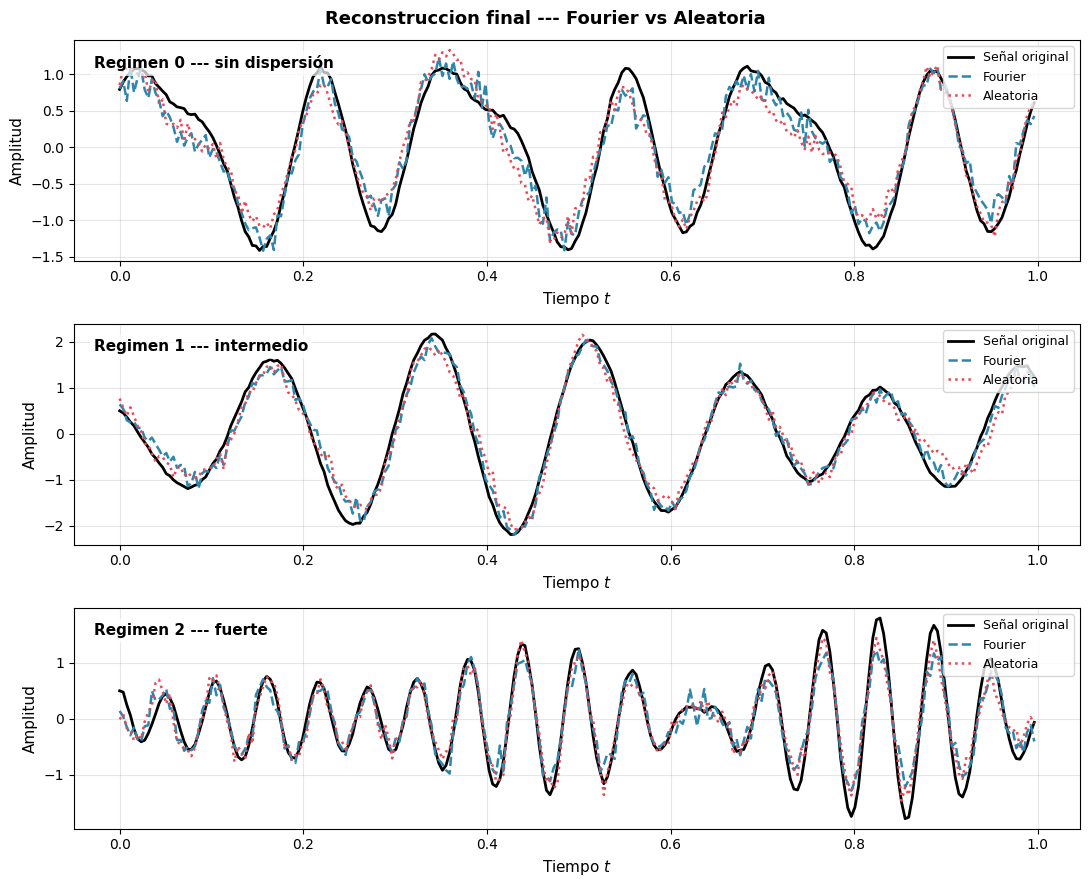

In [20]:
# figura con 3 paneles apilados verticalmente — uno por régimen
fig, axes = plt.subplots(3, 1, figsize=(11, 9))

# iteramos sobre los tres paneles y sus regímenes correspondientes
for ax, reg in zip(axes, [0, 1, 2]):

    # ── señal original ───────────────────────────────────────────────────
    # tomamos la primera señal del régimen actual como numpy array para graficar
    x_orig  = np.array(X[y == reg][0])                  # (256,)

    # ── reconstrucciones ─────────────────────────────────────────────────
    # pasamos x_orig por la red entrenada con inicialización Fourier
    # usamos los parámetros finales guardados en resultados_fourier
    # np.array(...) convierte la salida JAX a numpy para matplotlib
    x_rec_f = np.array(forward(resultados_fourier[reg]['params'],
                                jnp.array(x_orig)))      # (256,)

    # ídem con los parámetros de la red con inicialización aleatoria
    x_rec_r = np.array(forward(resultados_aleatorio[reg]['params'],
                                jnp.array(x_orig)))      # (256,)

    # ── graficar las tres curvas ──────────────────────────────────────────
    # señal original en negro sólido — es la referencia
    ax.plot(t, x_orig,  'k-',  lw=2,   label='Señal original')
    # reconstrucción Fourier en azul punteado
    ax.plot(t, x_rec_f, '--',  color='#2E86AB', lw=1.8, label='Fourier')
    # reconstrucción aleatoria en rojo punteado
    ax.plot(t, x_rec_r, ':',   color='#E84855', lw=1.8, label='Aleatoria')

    # ── título dentro del panel ───────────────────────────────────────────
    # ax.transAxes usa coordenadas relativas al panel (0,0)=inf.izq (1,1)=sup.der
    # posición (0.02, 0.93): esquina superior izquierda
    # bbox: fondo blanco semitransparente sin borde para que se lea sobre la curva
    ax.text(0.02, 0.93, nombres[reg],
            transform=ax.transAxes,
            fontsize=11, fontweight='bold',
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white', alpha=0.7, edgecolor='none'))

    ax.set_ylabel('Amplitud', fontsize=11)
    ax.set_xlabel('Tiempo $t$', fontsize=11)
    # leyenda en esquina superior derecha para no tapar las curvas
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle(r'Reconstruccion final --- Fourier vs Aleatoria',
             fontsize=13, fontweight='bold')
plt.tight_layout()   # ajusta espaciado entre paneles para evitar solapamiento
plt.show()

##**11.** Curva de $L$ vs iteraciones

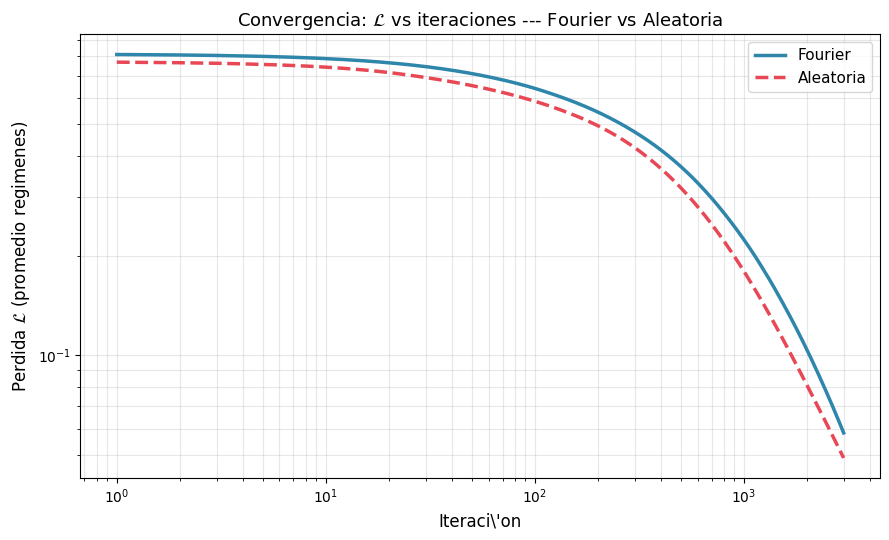

In [13]:
# ── Promedio de la pérdida sobre los tres regímenes ──────────────────────
# construimos una lista con los 3 historiales de pérdida (cada uno tiene 3000 valores)
# np.mean(..., axis=0) promedia en cada iteración sobre los 3 regímenes
# resultado: una sola curva de 3000 valores que representa el comportamiento global
loss_f_medio = np.mean([resultados_fourier[reg]['loss']   for reg in [0,1,2]], axis=0)
loss_r_medio = np.mean([resultados_aleatorio[reg]['loss'] for reg in [0,1,2]], axis=0)

# vector de iteraciones alineado con los historiales de pérdida
# cada historial tiene n_iter=3000 valores, uno por iteración
iters = np.arange(1, n_iter + 1)   # [1, 2, 3, ..., 3000]

fig, ax = plt.subplots(figsize=(9, 5.5))

# loglog: ambos ejes en escala logarítmica
# permite ver si la pérdida sigue una ley de potencia L ~ k^(-α)
# en ese caso las curvas aparecen como líneas rectas en log-log
ax.loglog(iters, loss_f_medio, '-',  color='#2E86AB', lw=2.5, label='Fourier')
ax.loglog(iters, loss_r_medio, '--', color='#E84855', lw=2.5, label='Aleatoria')

ax.set_xlabel(r'Iteraci\'on', fontsize=12)
ax.set_ylabel(r'Perdida $\mathcal{L}$ (promedio regimenes)', fontsize=12)
ax.set_title(r'Convergencia: $\mathcal{L}$ vs iteraciones --- Fourier vs Aleatoria',
             fontsize=13)
ax.legend(fontsize=11)
# which='both': activa el grid para las líneas principales (potencias de 10)
# y para las divisiones intermedias — útil en escala logarítmica
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

##**12.** iteraciones para bajar el error 0.1

In [14]:
# ── Experimento 1: más iteraciones para alcanzar err_rel < 0.1 ───────────
# con 3000 iteraciones ninguna inicialización bajaba de 0.1
# aumentamos a 20000 para ver si la arquitectura K=15 tiene capacidad suficiente
eta_exp1    = 0.05    # misma tasa de aprendizaje que el entrenamiento anterior
n_iter_exp1 = 20000   # 20000 iteraciones en vez de 3000

# usamos solo el régimen 0 — es donde la inicialización Fourier tiene ventaja
# y el enunciado pide prestar especial atención a este régimen
X_reg0 = jnp.array(X[y == 0], dtype=jnp.float32)   # (15, 256)

# diccionario para guardar resultados de ambas inicializaciones
resultados_exp1 = {}

# iteramos sobre las dos inicializaciones en el mismo loop
# cada elemento es un par (nombre, función que crea los parámetros iniciales)
# usamos lambda para que init_fn() cree parámetros frescos en cada iteración del loop
for nombre, init_fn in [('fourier',   lambda: init_fourier(K, t, key)),
                         ('aleatoria', lambda: init_random(K, N, key))]:

    # inicializar parámetros llamando a la función correspondiente
    params = init_fn()

    hist_loss    = []
    hist_err_rel = []

    for i in range(n_iter_exp1):
        # paso del gradiente descendente — igual que antes
        g      = grad_loss(params, X_reg0)
        params = jax.tree_util.tree_map(lambda p, g: p - eta_exp1 * g, params, g)

        # guardamos métricas cada 10 iteraciones en vez de cada 1
        # con 20000 iteraciones guardar todo generaría listas muy largas
        # y haría el loop más lento — cada 10 da suficiente resolución para graficar
        if i % 10 == 0:
            # pérdida MSE actual
            l     = float(loss_fn(params, X_reg0))

            # reconstrucciones de las 15 señales del régimen 0
            preds = vmap(lambda x: forward(params, x))(X_reg0)   # (15, 256)

            # error relativo promedio sobre las 15 señales
            err   = float((jnp.linalg.norm(preds - X_reg0, axis=1) /
                          jnp.linalg.norm(X_reg0, axis=1)).mean())
            hist_loss.append(l)
            hist_err_rel.append(err)

    # guardar resultados de esta inicialización
    resultados_exp1[nombre] = {
        'params'  : params,
        'loss'    : hist_loss,
        'err_rel' : hist_err_rel
    }

    # reportar si se alcanzó el umbral de error relativo 0.1
    print(f"{nombre:10s} ✓  |  err_rel final = {hist_err_rel[-1]:.4f}  "
          f"|  ¿bajó de 0.1? {hist_err_rel[-1] < 0.1}")

fourier    ✓  |  err_rel final = 0.0445  |  ¿bajó de 0.1? True
aleatoria  ✓  |  err_rel final = 0.0526  |  ¿bajó de 0.1? True


Como podemos observar, aumentando las iteraciones a 20000 logramos disminuir el error relativo por debajo de 0.1 con ambas inicializaciones.

Ahora veamos en qué iteración cada inicializacion cruza el umbral 0.1

In [15]:
def iter_umbral(hist, umbral, paso_guardado=10):
    # buscamos el primer índice i donde el error relativo baja del umbral
    # next(..., None) devuelve None si ningún valor cumple la condición
    # en vez de lanzar un error — manejo seguro del caso "no se alcanza"
    idx = next((i for i, v in enumerate(hist) if v < umbral), None)

    # como guardamos cada 10 iteraciones (paso_guardado=10),
    # el índice en la lista no es la iteración real:
    # índice 0 → iteración 0, índice 1 → iteración 10, índice 512 → iteración 5120
    # multiplicar por paso_guardado convierte el índice a iteración real
    return idx * paso_guardado if idx is not None else None

# buscar en qué iteración real cada inicialización cruza err_rel = 0.1
it_f_01 = iter_umbral(resultados_exp1['fourier']['err_rel'],   0.1)
it_r_01 = iter_umbral(resultados_exp1['aleatoria']['err_rel'], 0.1)

print(f"Fourier   baja de err_rel=0.1 en la iteración: {it_f_01}")
print(f"Aleatoria baja de err_rel=0.1 en la iteración: {it_r_01}")

# comparar velocidades solo si ambas alcanzaron el umbral
# (si alguna devolvió None, la comparación no tiene sentido)
if it_f_01 and it_r_01:
    if it_f_01 < it_r_01:
        # Fourier llegó primero — la diferencia es la ventaja en iteraciones
        print(f"\nFourier llega primero — {it_r_01 - it_f_01} iteraciones antes")
    else:
        # Aleatoria llegó primero
        print(f"\nAleatoria llega primero — {it_f_01 - it_r_01} iteraciones antes")

Fourier   baja de err_rel=0.1 en la iteración: 10240
Aleatoria baja de err_rel=0.1 en la iteración: 11160

Fourier llega primero — 920 iteraciones antes


 Fourier llega primero, aunque por un margen relativamente modesto (920 iteraciones de 20000, es decir ~4.6% de ventaja)



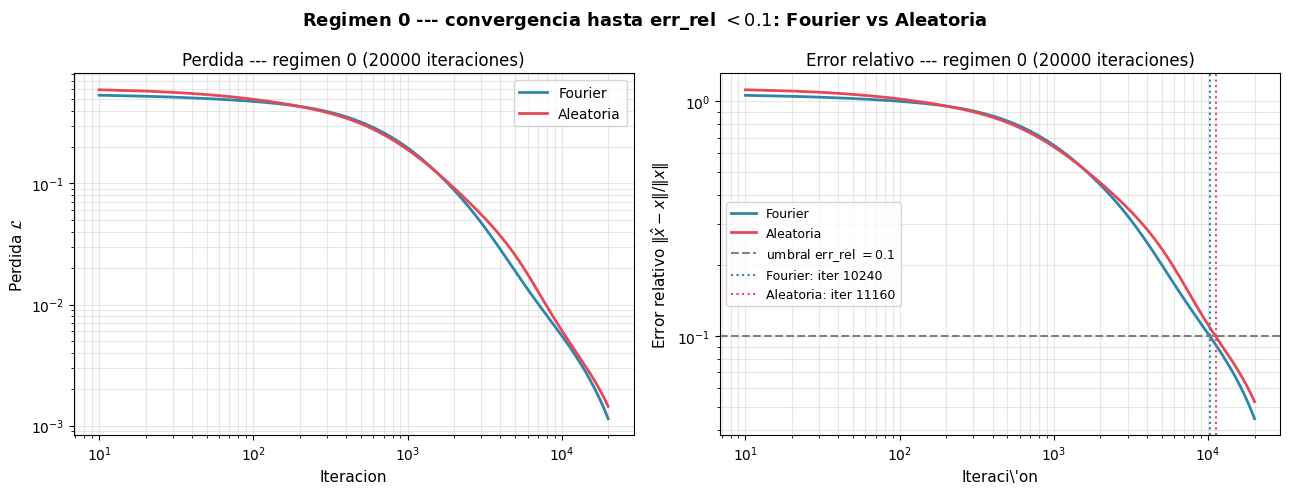

In [21]:
# eje de iteraciones alineado con los datos guardados — cada 10 pasos
iters_exp1 = np.arange(0, n_iter_exp1, 10)   # [0, 10, 20, ..., 19990] → 2000 puntos

# extraer historiales como arrays numpy para graficar
ef1 = np.array(resultados_exp1['fourier']['err_rel'])     # error relativo Fourier
er1 = np.array(resultados_exp1['aleatoria']['err_rel'])   # error relativo Aleatoria
hf1 = np.array(resultados_exp1['fourier']['loss'])        # pérdida Fourier
hr1 = np.array(resultados_exp1['aleatoria']['loss'])      # pérdida Aleatoria

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel izquierdo: pérdida en escala log-log ───────────────────────────
# loglog: ambos ejes logarítmicos — permite ver la tasa de decaimiento
# de la pérdida como pendiente de una línea recta
axes[0].loglog(iters_exp1[1:], hf1[1:], color='#2E86AB', lw=2, label='Fourier')
axes[0].loglog(iters_exp1[1:], hr1[1:], color='#E84855', lw=2, label='Aleatoria')
# nota: usamos [1:] para evitar iters_exp1[0]=0, cuyo log no está definido
axes[0].set_xlabel(r'Iteracion', fontsize=11)
axes[0].set_ylabel(r'Perdida $\mathcal{L}$', fontsize=11)
axes[0].set_title(r'Perdida --- regimen 0 (20000 iteraciones)', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, which='both')   # grid en potencias y divisiones intermedias

# ── Panel derecho: error relativo en escala log-log ──────────────────────
axes[1].loglog(iters_exp1[1:], ef1[1:], color='#2E86AB', lw=2, label='Fourier')
axes[1].loglog(iters_exp1[1:], er1[1:], color='#E84855', lw=2, label='Aleatoria')

# línea horizontal en el umbral 0.1 — referencia para medir velocidad de convergencia
axes[1].axhline(0.1, color='gray', ls='--', lw=1.5, label=r'umbral err_rel $= 0.1$')

# líneas verticales marcando la iteración exacta donde cada red cruza el umbral
axes[1].axvline(it_f_01, color='#2E86AB', ls=':', lw=1.5,
                label=f'Fourier: iter {it_f_01}')
axes[1].axvline(it_r_01, color='#E84855', ls=':', lw=1.5,
                label=f'Aleatoria: iter {it_r_01}')

axes[1].set_xlabel(r'Iteraci\'on', fontsize=11)
axes[1].set_ylabel(r'Error relativo $\|\hat{x}-x\|/\|x\|$', fontsize=11)
axes[1].set_title(r'Error relativo --- regimen 0 (20000 iteraciones)', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, which='both')

plt.suptitle(r'Regimen 0 --- convergencia hasta err_rel $< 0.1$: Fourier vs Aleatoria',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##**13.** analisis del regimen dificil

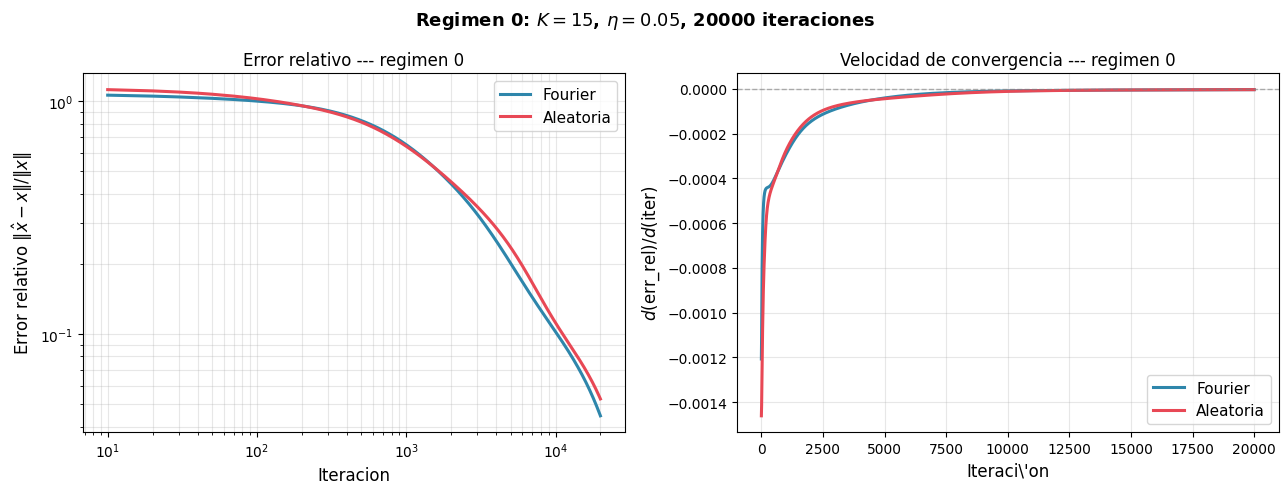

In [17]:
# ── Derivada numérica del error relativo ─────────────────────────────────
# np.gradient calcula d(err_rel)/d(iter) usando diferencias finitas centradas:
# para cada punto i: (err_rel[i+1] - err_rel[i-1]) / (iter[i+1] - iter[i-1])
# el resultado mide cuánto cambia el error por iteración — la velocidad de aprendizaje
# valores muy negativos → el error cae rápido
# valores cerca de cero → la red casi no mejora (convergencia)
def1 = np.gradient(ef1, iters_exp1)   # velocidad de convergencia — Fourier
der1 = np.gradient(er1, iters_exp1)   # velocidad de convergencia — Aleatoria

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel izquierdo: error relativo en log-log ───────────────────────────
# escala log-log permite ver el decaimiento del error como tendencia global
# omitimos el primer punto (iter=0) porque log(0) no está definido
axes[0].loglog(iters_exp1[1:], ef1[1:], color='#2E86AB', lw=2.2, label='Fourier')
axes[0].loglog(iters_exp1[1:], er1[1:], color='#E84855', lw=2.2, label='Aleatoria')
axes[0].set_xlabel(r'Iteracion', fontsize=12)
axes[0].set_ylabel(r'Error relativo $\|\hat{x} - x\| / \|x\|$', fontsize=12)
axes[0].set_title(r'Error relativo --- regimen 0', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3, which='both')   # grid en potencias y divisiones intermedias

# ── Panel derecho: derivada en escala lineal ─────────────────────────────
# la derivada tiene valores negativos (el error baja) — no se puede usar log
# escala lineal permite ver claramente el pico inicial de aprendizaje rápido
# y la desaceleración progresiva hacia cero
axes[1].plot(iters_exp1, def1, color='#2E86AB', lw=2.2, label='Fourier')
axes[1].plot(iters_exp1, der1, color='#E84855', lw=2.2, label='Aleatoria')

# línea de referencia en y=0: cuando las curvas la tocan, la red dejó de mejorar
axes[1].axhline(0, color='gray', ls='--', lw=1, alpha=0.6)
axes[1].set_xlabel(r'Iteraci\'on', fontsize=12)
axes[1].set_ylabel(r'$d(\mathrm{err\_rel})/d(\mathrm{iter})$', fontsize=12)
axes[1].set_title(r'Velocidad de convergencia --- regimen 0', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    r'Regimen 0: $K=15$, $\eta=0.05$, 20000 iteraciones',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##**14.** error de reconstrucción vs número de coeficientes conservados.

In [18]:
# rango de frecuencias a evaluar: k = 1, 2, ..., K=15
k_range = np.arange(1, K + 1)

# listas que acumularán los resultados para cada señal
errores_compresion = []   # error relativo de reconstrucción para cada (señal, k)
energia_acumulada  = []   # fracción de energía capturada para cada (señal, k)

# iteramos sobre las 45 señales del dataset completo (los tres regímenes)
for x_sig in X:

    # FFT completa de la señal — contiene toda la información frecuencial
    fft_full = np.fft.fft(x_sig)   # (256,) — coeficientes complejos

    # energía total de la señal en el dominio frecuencial
    # por el teorema de Parseval: igual a la energía en el dominio del tiempo
    energia_total = (np.abs(fft_full) ** 2).sum()

    errs  = []   # errores de reconstrucción para esta señal con k=1..K
    energ = []   # energía capturada para esta señal con k=1..K

    for k in k_range:
        # construir FFT truncada conservando solo los primeros k coeficientes
        fft_trunc = np.zeros_like(fft_full)

        # frecuencias positivas: índices 0 a k (componente DC + k armónicos)
        fft_trunc[:k+1]  = fft_full[:k+1]

        # frecuencias negativas: simétricas a las positivas (propiedad de señales reales)
        # sin esta línea la señal reconstruida tendría parte imaginaria no nula
        fft_trunc[-(k):] = fft_full[-(k):]

        # reconstruir la señal aplicando la FFT inversa
        # .real descarta la parte imaginaria residual (error numérico de ~1e-14)
        x_rec = np.fft.ifft(fft_trunc).real   # (256,)

        # error relativo de reconstrucción con k coeficientes
        # mide qué fracción de la señal no pudo ser reconstruida
        err = np.linalg.norm(x_rec - x_sig) / np.linalg.norm(x_sig)
        errs.append(float(err))

        # energía capturada por los primeros k coeficientes
        # el factor 2 cuenta la contribución simétrica de frecuencias positivas y negativas
        # min(..., 1.0) evita que errores numéricos den valores ligeramente mayores a 1
        energia_cap = 2 * (np.abs(fft_full[1:k+1]) ** 2).sum() / energia_total
        energ.append(float(min(energia_cap, 1.0)))

    # guardar los K valores de esta señal
    errores_compresion.append(errs)
    energia_acumulada.append(energ)

# convertir a matrices numpy: shape (45, 15)
# filas = señales, columnas = número de coeficientes k
errores_compresion = np.array(errores_compresion)
energia_acumulada  = np.array(energia_acumulada)

# promediar sobre las 45 señales (axis=0) para obtener curvas representativas
# resultado: un valor por cada k, promediado sobre todo el dataset
err_medio   = errores_compresion.mean(axis=0)   # (15,)
energ_medio = energia_acumulada.mean(axis=0)    # (15,)

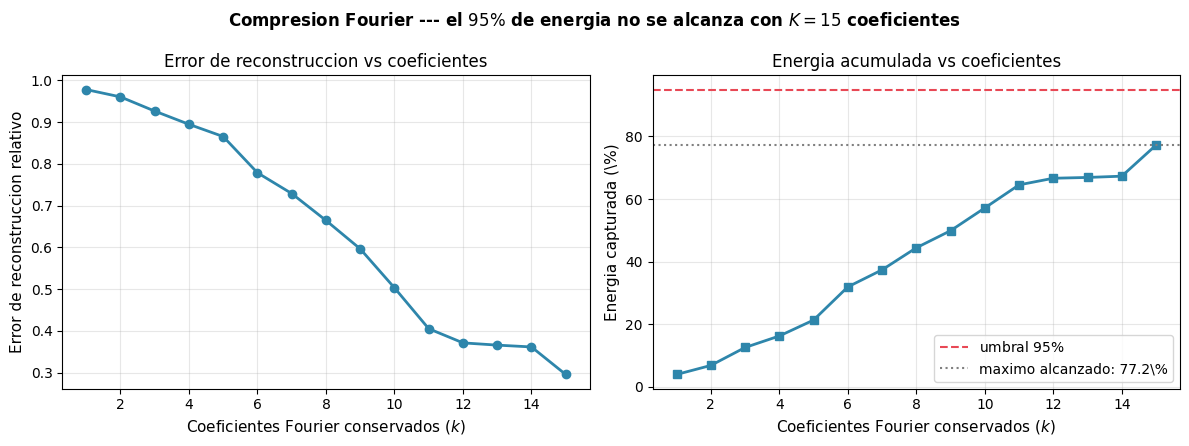

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── Panel izquierdo: error de reconstrucción vs coeficientes ─────────────
# 'o-': círculos en cada punto k conectados por una línea
# muestra cómo mejora la reconstrucción al añadir cada frecuencia
axes[0].plot(k_range, err_medio, 'o-', color='#2E86AB', lw=2, ms=6)
axes[0].set_xlabel(r'Coeficientes Fourier conservados ($k$)', fontsize=11)
axes[0].set_ylabel(r'Error de reconstruccion relativo', fontsize=11)
axes[0].set_title(r'Error de reconstruccion vs coeficientes', fontsize=12)
axes[0].grid(True, alpha=0.3)

# ── Panel derecho: energía acumulada vs coeficientes ─────────────────────
# energ_medio * 100 convierte fracción [0,1] a porcentaje [0,100]
# 's-': cuadrados en cada punto k conectados por una línea
axes[1].plot(k_range, energ_medio * 100, 's-', color='#2E86AB', lw=2, ms=6)

# línea de referencia en 95% — umbral de energía pedido por el enunciado
axes[1].axhline(95, color='#E84855', ls='--', lw=1.5, label=r'umbral $95\%$')

# línea en el máximo alcanzado con K=15 — muestra cuánto falta para llegar al 95%
# energ_medio[-1] es el valor en k=K=15, el último punto de la curva
axes[1].axhline(energ_medio[-1]*100, color='gray', ls=':', lw=1.5,
                label=rf'maximo alcanzado: {energ_medio[-1]*100:.1f}\%')

axes[1].set_xlabel(r'Coeficientes Fourier conservados ($k$)', fontsize=11)
axes[1].set_ylabel(r'Energia capturada (\%)', fontsize=11)
axes[1].set_title(r'Energia acumulada vs coeficientes', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    rf'Compresion Fourier --- el $95\%$ de energia no se alcanza con $K={K}$ coeficientes',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Panel izquierdo — Error de reconstrucción vs coeficientes**

El eje horizontal es k (número de frecuencias conservadas, de 1 a 15) y el eje vertical es el error relativo $\|\hat{x} - x\| / \|x\|$ promediado sobre las 45 señales.
La curva tiene tres comportamientos distintos:

* De k=1 a k=11 — caída sostenida El error baja de ~0.98 a ~0.40. Cada frecuencia que añades aporta información nueva que mejora la reconstrucción. Con k=1 solo tienes la frecuencia más baja — la reconstrucción es pésima, el error es casi 1 (el error es casi tan grande como la señal misma). Con k=11 ya capturas bastante estructura de la señal.

* De k=11 a k=14 — meseta El error se estabiliza alrededor de 0.35-0.37 y casi no mejora. Esto significa que las frecuencias k=12,13,14 aportan muy poca información nueva — tienen coeficientes pequeños y su contribución a la reconstrucción es mínima.

* En k=15 — caída brusca El error baja repentinamente a ~0.30. La frecuencia k=15 tiene coeficientes grandes — aporta información importante que estaba ausente en k=12,13,14.

&nbsp;

**Panel derecho — Energía acumulada vs coeficientes**
El eje horizontal es el mismo k y el eje vertical es el porcentaje de energía total capturada por los primeros k coeficientes.

como cada k aporta dos coeficientes: $a_k$(coseno) y $b_k$(seno). La energía que aporta la frecuencia k es:

$E_k = 2 \cdot |\hat{x}[k]|^2$

Y la energía acumulada hasta k es:

$\text{energía}(k) = \frac{\sum_{j=1}^{k} E_j}{\sum_{j=0}^{255} E_j} \times 100\$

La curva muestra tres cosas importantes:

* Crecimiento lento al principio (k=1 a k=5)Las primeras frecuencias capturan poca energía — entre 4% y 21%. Esto significa que las señales no están dominadas por frecuencias bajas. Tiene sentido físicamente: el parámetro $\mu > 0$ en los regímenes 1 y 2 empuja las frecuencias hacia arriba, alejándolas de k=1.

* Salto en k=6, La energía salta de 21% a 32% — la frecuencia k=6 tiene coeficientes grandes en muchas señales del dataset. Es la frecuencia más "importante" del conjunto.

* Crecimiento irregular de k=6 a k=15 La energía sigue subiendo pero de forma desigual — algunas frecuencias aportan mucho (k=6, k=10, k=11, k=15) y otras muy poco (k=12, k=13, k=14). Esto corresponde exactamente a la meseta del panel izquierdo

* La línea roja punteada (95%) queda muy por encima de la curva azul — nunca se alcanza. Con k=15 solo llegamos al 77.2% (línea gris punteada).

&nbsp;

**¿Por qué no se alcanza el 95%?**

Hay una razón física directa. Las señales del dataset son:
$f(t) = \sum_j a_j \cos(\omega(k_j) t + \varphi_j)$

donde $\omega(k) = \sqrt{c^2 k^2 + \mu^2}$ En los regímenes 1 y 2, el término $\mu^2$ hace que incluso frecuencias con k pequeño oscilen rápido — lo que en el dominio de Fourier se traduce en que la energía se distribuye entre muchas frecuencias, incluyendo k>15.
Nuestra capa Fourier solo llega hasta K=15. El 22.8% de energía restante vive en frecuencias k>15 que están completamente fuera del alcance de la red. Para capturar el 95% necesitaríamos aumentar K — probablemente a $K \approx 30$ o más dependiendo del régimen.

&nbsp;

Los dos paneles cuentan la misma historia desde ángulos distintos:

Donde la energía acumulada salta (k=6, k=10, k=11, k=15) → el error de reconstrucción cae
Donde la energía acumulada se estanca (k=12, k=13, k=14) → el error forma la meseta

Son dos caras de la misma moneda: añadir una frecuencia con mucha energía mejora la reconstrucción; añadir una con poca energía no cambia casi nada.

##**conclusión: ¿Conviene inicializar en la base de Fourier?**

La pregunta central de esta evaluación fue: ¿ayuda empezar con la base "correcta" (Fourier) en lugar de una base aleatoria? Después de entrenar la red en los tres regímenes, medir errores de reconstrucción, comparar velocidades de convergencia y explorar la compresión, la respuesta es: depende del régimen físico de la señal.

**Lo que encontramos**

La inicialización Fourier construye $W_1$​ como una matriz de senos y cosenos — verificamos que reproduce exactamente la transformada de Fourier de la señal (error máximo $\approx 10^{-14}$). Esto significa que desde el primer paso del entrenamiento, la red ya tiene una representación estructurada de la señal. La inicialización aleatoria, en cambio, parte del ruido y tiene que construir esa representación desde cero.
Sin embargo, esa ventaja inicial no se traduce siempre en mejor resultado final. Entrenando 3000 iteraciones con $\eta = 0.05$ y K=15 frecuencias:


| Régimen | Frecuencias dominantes | ¿Quién tiene menor error? |
| --- | --- | --- |
| 0 — sin dispersión | k≤11 (bajas) | Fourier |
| 1 — intermedio| k≤12 (medias) | Aleatoria |
| 2 — fuerte | k=15-19 (altas) | Aleatoria |


Fourier solo gana en el régimen 0, que es precisamente donde las frecuencias dominantes de las señales (k = 2, 3, 6, 10, 11) están completamente dentro del rango de los K=15 modos. En ese régimen, la base de Fourier es realmente la "base correcta" y el punto de partida ya es una buena aproximación.

En los regímenes 1 y 2, las frecuencias relevantes se desplazan hacia valores más altos — efecto del término $\mu^2$ en la relación de dispersión $\omega(k) = \sqrt{c^2k^2 + \mu^2}$ En el régimen 2, los picos de energía están en k=15-19, fuera del alcance de $W_1$​. En ese caso, la inicialización Fourier es un punto de partida equivocado: la red tiene que "desaprender" esa estructura antes de poder mejorar, mientras que la inicialización aleatoria tiene más libertad para encontrar una representación útil.

**Velocidad de convergencia**

Donde sí se ve una ventaja consistente de Fourier es en la velocidad de convergencia del régimen 0. Entrenando hasta 20000 iteraciones, ambas inicializaciones logran bajar el error relativo por debajo de 0.1, pero Fourier lo alcanza en la iteración 10240 y la aleatoria en la 11160 — una ventaja de 920 iteraciones (~4.6%). La curva de error relativo muestra que Fourier está consistentemente por debajo durante todo el entrenamiento, no solo al final.

Esa ventaja existe pero no es enorme. La razón es que con K=15 modos, incluso la base Fourier captura solo el 77% de la energía promedio del dataset — el 23% restante está en frecuencias k>15. Ese "último tramo" hacia el error bajo lo recorren ambas redes a velocidad similar, porque ninguna tiene acceso directo a esa energía perdida y tienen que compensarla ajustando $W_1$ y $W_2$​ durante el entrenamiento.

El ultimo experimento confirmó esta limitación: con K=15 coeficientes no se alcanza el umbral del 95% de energía en ningún régimen del dataset completo. Las frecuencias de los regímenes 1 y 2 se extienden más allá de k=15, lo que establece un piso teórico en el error de reconstrucción que ninguna inicialización puede superar con esta arquitectura.

**Respuesta final**

Inicializar en la base de Fourier conviene cuando se sabe de antemano que las señales tienen frecuencias bajas — es decir, cuando la base Fourier con K modos realmente cubre la mayor parte de la energía de la señal. En ese caso da una ventaja de velocidad real y un mejor punto de partida.
Cuando las señales tienen frecuencias altas o la energía está distribuida más allá de K modos, la inicialización Fourier puede ser contraproducente — la red aleatoria converge mejor porque no está "atada" a una representación que no encaja con la señal. En esos casos, lo que realmente ayudaría no es cambiar la inicialización sino aumentar K para que la arquitectura tenga capacidad suficiente para representar todas las frecuencias relevantes.







